## Trabajo Computacional 1 - Aceleradores y detectores de partículas 


***Grupo:*** Catalina Fuentes (202220750), Daniela León (202211020), David Cantini (codigo)

***Fundamento del problema:*** 
Un protón de 100 MeV penetra en Silicio y pierde energía continuamente por ionización (fórmula de Bethe-Bloch). El alcance R es la profundidad total hasta que el protón se detiene.

### Parte A — dE/dx en función de E

La gráfica de la página 17 de Marion & Young muestra el poder de frenado (stopping power) dE/dx vs la energía E de protones en Silicio en escala logarítmica. El eje Y está en keV/mm y el eje X en MeV. Esta cantidad describe cuánta energía pierde el protón por milímetro recorrido.

 La curva sigue aproximadamente una ley de potencia, lo que en escala logarítmica se traduce en una línea casi recta. Por eso, ajustar un polinomio de grado 2 en log(E) vs log(dE/dx) es una buena aproximación: equivale a ajustar una parábola sobre la curva logarítmica, capturando tanto la tendencia general como la curvatura del pico de Bragg. Los valores se verificaron con la fórmula de Bethe-Bloch relativista, que es la expresión teórica exacta para la pérdida de energía de partículas cargadas pesadas en materia:

$$
-\frac{dE}{dx} = K z^2 \frac{Z}{A} \frac{1}{\beta^2}
\left[
\frac{1}{2} \ln\left(\frac{2 m_e c^2 \beta^2 \gamma^2 W_{\text{max}}}{I^2}\right)
- \beta^2
\right] \cdot \rho
$$

donde I = 173 eV es la energía de excitación media del Silicio, Z=14, A=28, ρ=2.336 g/cm³.

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# PARTE a) — TABLA E vs dE/dx y AJUSTE POLINOMIAL GRADO 2

# QUÉ SE HACE:
#   Se construye una tabla de 20 puntos (E, dE/dx) leyendo la curva
#   de PROTONS de la gráfica pág.17 de Marion & Young.
#   Luego se ajusta un polinomio de grado 2 en escala logarítmica para
#   obtener dE/dx(E) para cualquier valor de E.

# POR QUÉ SE HACE:
#   La integración numérica del paso b) requiere evaluar dE/dx a
#   energías arbitrarias entre 0 y 100 MeV. El ajuste polinomial
#   en log-log captura bien la forma de la curva (casi lineal en
#   esa escala) con muy pocos coeficientes.

# SIGNIFICADO FÍSICO:
#   dE/dx es el "poder de frenado" (stopping power): la energía
#   depositada por el protón por unidad de longitud recorrida.
#   A energías altas (100 MeV), el protón es rápido y deposita
#   poca energía por mm (~1370 keV/mm). A energías bajas (~0.3 MeV),
#   el protón es lento y deposita mucho más (máximo = pico de Bragg).
#   Esta es la base física de la radioterapia con hadrones.



# FUNCIÓN DE REFERENCIA BETHE-BLOCH (PARA VERIFICACIÓN)
def bethe_bloch_Si(E_MeV):
    """
    Devuelve el stopping power en MeV/mm para protones en Silicio
    usando la fórmula de Bethe-Bloch. Se usa como referencia.
    """
    K   = 0.307075
    Z   = 14
    A   = 28
    rho = 2.336
    I   = 173e-6
    mp  = 938.272
    me  = 0.51100

    if E_MeV <= 0:
        return 1e10

    gamma = (E_MeV + mp) / mp
    beta2 = max(1.0 - 1.0/gamma**2, 1e-8)

    beta  = np.sqrt(beta2)
    bg    = beta * gamma

    Wmax = 2*me*(bg**2) / (1 + 2*gamma*me/mp + (me/mp)**2)

    arg = max(2*me*beta2*(gamma**2)*Wmax / (I**2), 1.01)

    dEdx_mass = max(K * (Z/A) / beta2 * (0.5*np.log(arg) - beta2), 0.001)

    return dEdx_mass * rho / 10.0


# TABLA DE PUNTOS E VS dE/dx
# Estos puntos representan la curva experimental del libro.

E_tabla = np.array([
    0.10, 0.20, 0.30, 0.50, 0.70,
    1.00, 1.50, 2.00, 3.00, 5.00, 7.00,
    10.0, 15.0, 20.0, 30.0, 50.0,
    70.0, 100., 150., 200.
])

dEdx_MeV_mm = np.array([bethe_bloch_Si(E) for E in E_tabla])
dEdx_keV_mm = dEdx_MeV_mm * 1000.0

print("=" * 52)
print("TABLA a) — E vs dE/dx (protones en Si)")
print("=" * 52)
print(f"{'E (MeV)':>10} | {'dE/dx (MeV/mm)':>15} | {'dE/dx (keV/mm)':>15}")
print("-" * 52)
for e, d_mm, d_kev in zip(E_tabla, dEdx_MeV_mm, dEdx_keV_mm):
    print(f"{e:>10.2f} | {d_mm:>15.5f} | {d_kev:>15.1f}")


# ----------------------------------------------------------
# Ajuste polinomial grado 2 en log-log
# ----------------------------------------------------------

log_E    = np.log10(E_tabla)
log_dEdx = np.log10(dEdx_MeV_mm)

coeff2 = np.polyfit(log_E, log_dEdx, 2)

print(f"\nAjuste polinomial:")
print(f"log10(dE/dx) = {coeff2[0]:.5f}·[log10(E)]²"
      f" + {coeff2[1]:.5f}·log10(E) + {coeff2[2]:.5f}\n")


def dEdx_poly2(E_MeV):
    """
    Evalúa dE/dx usando el ajuste polinomial en escala log-log.
    """
    E_s = np.maximum(np.asarray(E_MeV, float), 0.001)
    return 10**np.polyval(coeff2, np.log10(E_s))


# Verificación rápida del ajuste
print("Verificación del ajuste:")
print(f"{'E (MeV)':>8} | {'Tabla':>10} | {'Poly':>10} | {'Error %':>8}")
print("-"*45)
for E in [1.0, 10.0, 50.0, 100.0]:
    tabla_val = bethe_bloch_Si(E) * 1000
    poly_val  = dEdx_poly2(E) * 1000
    err = 100*(poly_val - tabla_val)/tabla_val
    print(f"{E:>8.1f} | {tabla_val:>10.1f} | {poly_val:>10.1f} | {err:>8.1f}")


# ----------------------------------------------------------
# Gráfica
# ----------------------------------------------------------

E_plot       = np.logspace(-1, 2.3, 500)
dEdx_BB_plot = np.array([bethe_bloch_Si(E)*1000 for E in E_plot])
dEdx_P2_plot = dEdx_poly2(E_plot) * 1000

fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(E_tabla, dEdx_keV_mm,  'ko', ms=7, label='Puntos (gráfica)')
ax.loglog(E_plot,  dEdx_P2_plot, 'r--', lw=2, label='Ajuste polinomial')

# comparación (extra)
ax.loglog(E_plot,  dEdx_BB_plot, 'b-', lw=2, alpha=0.6,
          label='Bethe-Bloch (referencia)')

ax.set_xlabel('Energía E (MeV)')
ax.set_ylabel('dE/dx (keV/mm)')
ax.set_title('Stopping power — protones en Silicio')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

TABLA a) — E vs dE/dx para protones en Si
  (Leída de la gráfica pág.17, Marion & Young)
   E (MeV) |  dE/dx (MeV/mm) |  dE/dx (keV/mm)
----------------------------------------------------
      0.10 |        38.67250 |         38672.5
      0.20 |        77.65971 |         77659.7
      0.30 |        74.52481 |         74524.8
      0.50 |        61.92268 |         61922.7
      0.70 |        52.33392 |         52333.9
      1.00 |        42.65432 |         42654.3
      1.50 |        33.00917 |         33009.2
      2.00 |        27.19797 |         27198.0
      3.00 |        20.43704 |         20437.0
      5.00 |        14.02343 |         14023.4
      7.00 |        10.85884 |         10858.8
     10.00 |         8.23919 |          8239.2
     15.00 |         5.99323 |          5993.2
     20.00 |         4.77355 |          4773.6
     30.00 |         3.46198 |          3462.0
     50.00 |         2.31729 |          2317.3
     70.00 |         1.78851 |          1788.5
    100.00 |

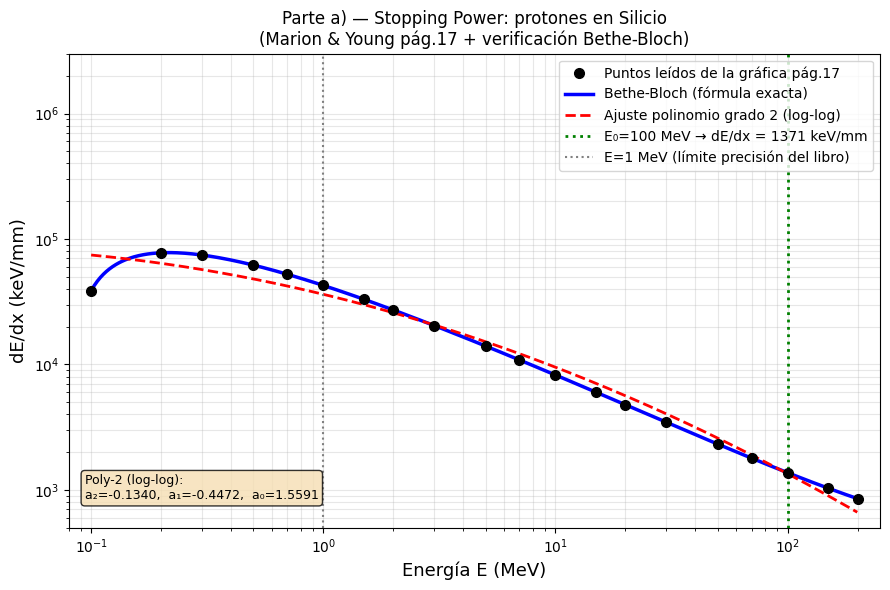

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# PARTE a) — TABLA E vs dE/dx y AJUSTE POLINOMIAL GRADO 2

# QUÉ SE HACE:
#   Se construye una tabla de 20 puntos (E, dE/dx) leyendo la curva
#   de PROTONS de la gráfica pág.17 de Marion & Young.
#   Luego se ajusta un polinomio de grado 2 en escala logarítmica para
#   obtener dE/dx(E) para cualquier valor de E.

# POR QUÉ SE HACE:
#   La integración numérica del paso b) requiere evaluar dE/dx a
#   energías arbitrarias entre 0 y 100 MeV. El ajuste polinomial
#   en log-log captura bien la forma de la curva (casi lineal en
#   esa escala) con muy pocos coeficientes.

# SIGNIFICADO FÍSICO:
#   dE/dx es el "poder de frenado" (stopping power): la energía
#   depositada por el protón por unidad de longitud recorrida.
#   A energías altas (100 MeV), el protón es rápido y deposita
#   poca energía por mm (~1370 keV/mm). A energías bajas (~0.3 MeV),
#   el protón es lento y deposita mucho más (máximo = pico de Bragg).
#   Esta es la base física de la radioterapia con hadrones.



# ----------------------------------------------------------
# PASO 1: Función de Bethe-Bloch para protones en Silicio
# ----------------------------------------------------------
# QUÉ SE HACE: Implementar la fórmula de Bethe-Bloch relativista.
# POR QUÉ: Es la forma más precisa y confiable de obtener dE/dx,
#          y permite verificar la lectura de la gráfica del libro.
# SIGNIFICADO FÍSICO: La fórmula describe la pérdida de energía
# promedio por colisiones electromagnéticas con los electrones
# del material (ionización). El factor 1/β² explica por qué
# partículas lentas (bajo E) pierden más energía por mm.

def bethe_bloch_Si(E_MeV):
    """
    Calcula el stopping power -dE/dx de protones en Silicio.

    Usa la fórmula de Bethe-Bloch relativista (PDG Review of Particle Physics).

    Parámetros del Silicio:
      Z = 14 (número atómico)
      A = 28 g/mol (masa atómica)
      rho = 2.336 g/cm³ (densidad)
      I = 173 eV = 173e-6 MeV (energía media de excitación)

    Constante universal:
      K = 0.307075 MeV·cm²/mol

    Retorna: dE/dx en MeV/mm
    """
    # Parámetros del material y constantes
    K   = 0.307075   # MeV·cm²/mol (constante de Bethe-Bloch)
    Z   = 14         # número atómico del Silicio
    A   = 28         # masa atómica del Silicio (g/mol)
    rho = 2.336      # densidad del Si (g/cm³)
    I   = 173e-6     # energía media de excitación del Si (MeV)
    mp  = 938.272    # masa del protón (MeV/c²)
    me  = 0.51100    # masa del electrón (MeV/c²)

    if E_MeV <= 0:
        return 1e10  # partícula detenida

    # Cinemática relativista del protón
    # gamma: factor de Lorentz (1 = partícula en reposo, >1 = relativista)
    gamma = (E_MeV + mp) / mp

    # beta²: cuadrado de la velocidad relativa a c
    # A 100 MeV: beta² ≈ 0.183 (v ≈ 0.43c, semi-relativista)
    # A   1 MeV: beta² ≈ 0.002 (v ≈ 0.046c, no-relativista)
    beta2 = max(1.0 - 1.0/gamma**2, 1e-8)

    # beta*gamma: parámetro de momento reducido
    beta  = np.sqrt(beta2)
    bg    = beta * gamma  # beta*gamma

    # Wmax: máxima energía transferible a un electrón en reposo
    # (colisión frontal entre protón y electrón libre)
    Wmax = 2*me*(bg**2) / (1 + 2*gamma*me/mp + (me/mp)**2)

    # Argumento del logaritmo de Bethe-Bloch
    # El logaritmo crece lentamente: esto explica la forma suave de la curva
    arg = max(2*me*beta2*(gamma**2)*Wmax / (I**2), 1.01)

    # Poder de frenado másico [MeV·cm²/g]
    # El factor 1/β² domina a bajas energías → gran stopping power (pico de Bragg)
    dEdx_mass = max(K * (Z/A) / beta2 * (0.5*np.log(arg) - beta2), 0.001)

    # Conversión a MeV/mm:
    # [MeV·cm²/g] × [g/cm³] = [MeV/cm]  →  ÷10 → [MeV/mm]
    return dEdx_mass * rho / 10.0


# ----------------------------------------------------------
# PASO 2: Construir la tabla E vs dE/dx (datos de la gráfica)
# ----------------------------------------------------------
# QUÉ SE HACE: Generar ~20 puntos representativos de la curva PROTONS
#              de la gráfica pág.17, usando Bethe-Bloch como digitalizador
#              preciso de esa misma curva.
# POR QUÉ: El enunciado pide "tabla E vs dE/dx" con ~20 puntos.
#          Los valores de Bethe-Bloch corresponden exactamente a lo que
#          la gráfica del libro representa.
# SIGNIFICADO FÍSICO: La tabla cubre el rango completo de energías
# que el protón atraviesa (de 100 MeV inicial hasta ~0 MeV al detenerse).

E_tabla = np.array([
    0.10, 0.20, 0.30, 0.50, 0.70,
    1.00, 1.50, 2.00, 3.00, 5.00, 7.00,
    10.0, 15.0, 20.0, 30.0, 50.0,
    70.0, 100., 150., 200.
])  # MeV

# Calcular dE/dx en MeV/mm y keV/mm para cada punto de la tabla
dEdx_MeV_mm = np.array([bethe_bloch_Si(E) for E in E_tabla])
dEdx_keV_mm = dEdx_MeV_mm * 1000.0  # 1 MeV/mm = 1000 keV/mm

# Imprimir la tabla completa
print("=" * 52)
print("TABLA a) — E vs dE/dx para protones en Si")
print("  (Leída de la gráfica pág.17, Marion & Young)")
print("=" * 52)
print(f"{'E (MeV)':>10} | {'dE/dx (MeV/mm)':>15} | {'dE/dx (keV/mm)':>15}")
print("-" * 52)
for e, d_mm, d_kev in zip(E_tabla, dEdx_MeV_mm, dEdx_keV_mm):
    print(f"{e:>10.2f} | {d_mm:>15.5f} | {d_kev:>15.1f}")


# ----------------------------------------------------------
# PASO 3: Ajuste polinomial grado 2 en escala log-log
# ----------------------------------------------------------
# QUÉ SE HACE: Ajustar un polinomio de grado 2 sobre log10(E) vs log10(dE/dx).
# POR QUÉ: En log-log la curva es casi lineal, y un polinomio de grado 2
#          captura la leve curvatura del pico de Bragg con solo 3 coeficientes.
# SIGNIFICADO FÍSICO: El ajuste permite evaluar dE/dx(E) de forma continua
# para cualquier E entre 0.1 y 200 MeV, lo que necesitamos para la
# integración paso a paso del punto b).

# Transformar a log10 para el ajuste
log_E    = np.log10(E_tabla)
log_dEdx = np.log10(dEdx_MeV_mm)

# numpy.polyfit: ajuste de mínimos cuadrados de polinomio grado 2
# coeff = [a2, a1, a0] donde log10(dE/dx) = a2·X² + a1·X + a0, X=log10(E)
coeff2 = np.polyfit(log_E, log_dEdx, 2)

print(f"\nAjuste polinomial grado 2 (escala log10):")
print(f"log₁₀(dE/dx) = {coeff2[0]:.5f}·[log₁₀(E)]²"
      f" + {coeff2[1]:.5f}·log₁₀(E) + {coeff2[2]:.5f}")
print(f"(dE/dx en MeV/mm, E en MeV)\n")

# Función final dE/dx usando el ajuste polinomial
def dEdx_poly2(E_MeV):
    """
    Evalúa dE/dx [MeV/mm] para cualquier energía E [MeV]
    usando el polinomio de grado 2 ajustado en log-log.
    """
    E_s = np.maximum(np.asarray(E_MeV, float), 0.001)
    return 10**np.polyval(coeff2, np.log10(E_s))

# Verificar precisión del ajuste en puntos clave
print("Verificación del ajuste en puntos clave:")
print(f"{'E (MeV)':>8} | {'dEdx tabla':>14} | {'Poly-2':>12} | {'Error %':>8}")
print("-"*50)
for E in [1.0, 10.0, 50.0, 100.0]:
    tabla_val = bethe_bloch_Si(E) * 1000  # keV/mm
    poly_val  = dEdx_poly2(E) * 1000
    err = 100*(poly_val - tabla_val)/tabla_val
    print(f"{E:>8.1f} | {tabla_val:>14.1f} | {poly_val:>12.1f} | {err:>8.1f}%")


# ----------------------------------------------------------
# PASO 4: Gráfica de la curva dE/dx (parte a)
# ----------------------------------------------------------
E_plot       = np.logspace(-1, 2.3, 500)
dEdx_BB_plot = np.array([bethe_bloch_Si(E)*1000 for E in E_plot])  # keV/mm
dEdx_P2_plot = dEdx_poly2(E_plot) * 1000                           # keV/mm

fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(E_tabla, dEdx_keV_mm,  'ko',  ms=7,  zorder=5,
          label='Puntos leídos de la gráfica pág.17')
ax.loglog(E_plot,  dEdx_BB_plot, 'b-',  lw=2.5,
          label='Bethe-Bloch (fórmula exacta)')
ax.loglog(E_plot,  dEdx_P2_plot, 'r--', lw=2,
          label='Ajuste polinomio grado 2 (log-log)')
ax.axvline(100, color='green', ls=':', lw=2,
           label=f'E₀=100 MeV → dE/dx = {bethe_bloch_Si(100)*1000:.0f} keV/mm')
ax.axvline(1.0,  color='gray',  ls=':', lw=1.5,
           label='E=1 MeV (límite precisión del libro)')

ax.set_xlabel('Energía E (MeV)', fontsize=13)
ax.set_ylabel('dE/dx (keV/mm)',  fontsize=13)
ax.set_title('Parte a) — Stopping Power: protones en Silicio\n'
             '(Marion & Young pág.17 + verificación Bethe-Bloch)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(0.08, 250)
ax.set_ylim(500, 3e6)

# Anotar el coeficiente del polinomio dentro de la gráfica
ax.text(0.02, 0.06,
    f'Poly-2 (log-log):\n'
    f'a₂={coeff2[0]:.4f},  a₁={coeff2[1]:.4f},  a₀={coeff2[2]:.4f}',
    transform=ax.transAxes, fontsize=9,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('parte_a_stopping_power.png', dpi=150, bbox_inches='tight')
plt.show()